# Feature selection for downstream $N_2O$ modelling

This notebook assesses and validates the variables considered most important for downstream $N_2O$ modelling using the preprocessed and aligned, 10-minute resolution dataset. These variables were not originally selected through a formal feature selection procedure. Instead, they were identified earlier in the project as the most operationally and biologically relevant variables, based on literature review, process understanding, and exploratory data analysis. They also informed earlier preprocessing decisions, particularly when determining which periods of the dataset should be excluded due to long contiguous gaps in key signals.

For this reason, the purpose of this notebook is not to perform feature selection from scratch on the raw dataset. Rather, it is to evaluate whether the decisions to treat certain variables as most important are well supported by the processed data and remain justified as the core inputs for subsequent modelling. The analysis therefore provides validation of those earlier decisions, while also assessing whether any additional variables should be retained, deprioritised, or interpreted with caution.

This notebook draws on findings from both the global and localised exploratory data analysis completed prior. In particular, it examines whether variables identified as important in the literature and EDA continue to show meaningful relationships with $N_2O$ in the aligned dataset, and whether those relationships appear consistent enough to support their inclusion in forecasting and classification.

The analysis will consider feature importance from several complementary perspectives. This includes reviewing pairwise relationships with N2O, examining correlations between predictors, checking for redundancy and multicollinearity, and comparing simple statistical and model-based measures of relevance. Where appropriate, these findings will be interpreted in the context of the biological processes governing $N_2O$ production. The notebook also explores whether the selected variables retain useful explanatory and predictive signal for the continuous $N_2O$ response, using simple baseline regression models and feature ablation checks as a preliminary validation step before more advanced modelling.

Overall, this notebook is intended to provide a transparent and defensible justification for the variables carried forward into the modelling stage. The notebook therefore evaluates whether the variables that informed earlier preprocessing decisions remain well justified as core inputs for subsequent modelling.

The logic of the notebook is as follows.

1. Load the processed 10-minute dataset and define the candidate variables.
2. Assess each candidate variable's *marginal association* with the target `t1_n2o`.
3. Examine *redundancy between predictors* using correlation structure.
4. Quantify multicollinearity using VIF to identify variables that may be duplicating the same operational information.
5. Check whether dropping redundant variables actually harms predictive performance using simple Ridge-based comparisons.
6. Use a blocked time-series comparison as a more appropriate temporal validation check.
7. Summarise the evidence and retain the same final feature set for downstream modelling.

This ordering is important because each step answers a different question. Association with the target helps identify variables carrying signal; predictor–predictor correlation and VIF help identify overlap; and model-based comparisons check whether apparently redundant variables still add useful information when considered jointly.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from pathlib import Path
from IPython.display import display

from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import mutual_info_regression

from statsmodels.stats.outliers_influence import variance_inflation_factor

# Load the processed dataset.
# The notebook first looks for df_10T.csv in the current folder, then falls back to the
# original absolute path used during development.
candidate_paths = [
    Path("df_10T.csv"),
    Path(r"C:\Users\tomor\Documents\MSc Lecture Notes\Data Science Project\EDS_Design_Project\data\EDA\df_10T.csv"),
]

df_path = next((p for p in candidate_paths if p.exists()), None)
if df_path is None:
    raise FileNotFoundError(
        "Could not find 'df_10T.csv'. Place it in the same folder as this notebook "
        "or update the path in the loading cell."
    )

df = pd.read_csv(df_path)

print(f"Loaded dataset from: {df_path}")
print(f"Dataset shape: {df.shape}")

print("\nSummary statistics:")
display(df.describe())

print("\nFirst rows:")
display(df.head())

Loaded dataset from: C:\Users\tomor\Documents\MSc Lecture Notes\Data Science Project\EDS_Design_Project\data\EDA\df_10T.csv
Dataset shape: (105264, 35)

Summary statistics:


,total_airflow,t1_valve_pct,t1_n2o,t1_nh4,t1_no3,t1_do,t1_do_sp,t1_airflow,t1_ss,t1_temp,...,t1_phase_q,t1_airflow_q,t1_ss_q,t1_temp_q,phasecode_q,inlet_tank_q,outlet_tank_q,t1_po4_q,inflow_q,storm_mode_q
count,104189.000000,100620.000000,102459.000000,104188.000000,104190.000000,103782.000000,92561.000000,94565.000000,104190.000000,101370.000000,...,104162.0,94565.000000,104190.000000,101370.000000,92561.0,92561.0,92561.0,104138.000000,90758.000000,92561.0
mean,17132.238633,44.470745,0.128340,2.311437,3.116311,0.653175,0.655985,2187.268389,2.552777,15.660482,...,0.0,0.007423,0.136078,0.099724,0.0,0.0,0.0,0.036951,0.016913,0.0
std,6901.956401,40.266240,0.225140,2.200410,2.771673,0.569061,0.540993,2020.493134,0.852093,3.381279,...,0.0,0.085840,0.342873,0.299633,0.0,0.0,0.0,0.188642,0.128947,0.0
min,0.000000,0.000000,0.000000,0.004305,0.338735,0.004268,0.000000,0.000000,0.000000,8.437862,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0
25%,12190.833301,0.000000,0.014931,0.965082,1.526463,0.196036,0.000000,0.000000,2.133389,12.618092,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0
50%,16668.433398,43.500000,0.037731,1.869051,2.511774,0.437970,1.000000,2190.054934,2.548741,15.635127,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0
75%,21168.386328,85.740001,0.136227,3.022755,4.062157,1.042372,1.040527,3938.204852,2.957333,18.901096,...,0.0,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.0
max,43046.753906,99.099998,2.093171,20.009645,52.849318,10.886502,2.500000,10164.025195,8.780283,27.126736,...,0.0,1.000000,1.000000,1.000000,0.0,0.0,0.0,1.000000,1.000000,0.0



First rows:


,time,total_airflow,t1_valve_pct,t1_n2o,t1_nh4,t1_no3,t1_do,t1_do_sp,t1_airflow,t1_ss,...,t1_phase_q,t1_airflow_q,t1_ss_q,t1_temp_q,phasecode_q,inlet_tank_q,outlet_tank_q,t1_po4_q,inflow_q,storm_mode_q
0,2022-06-11 22:00:00+00:00,27927.583984,NaN,0.670255,1.490831,0.399823,0.457755,1.124573,NaN,1.511840,...,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0
1,2022-06-11 22:10:00+00:00,18362.584961,NaN,0.601157,1.644313,0.355465,0.919777,1.101837,NaN,1.496870,...,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0
2,2022-06-11 22:20:00+00:00,20433.400391,NaN,0.528009,2.219421,0.346612,0.519459,1.292950,NaN,1.514961,...,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0
3,2022-06-11 22:30:00+00:00,19882.449805,NaN,0.495718,2.272571,0.475687,1.570746,1.296754,NaN,1.481867,...,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0
4,2022-06-11 22:40:00+00:00,12538.500000,NaN,0.517824,2.424297,0.844169,0.922960,1.289009,NaN,1.518550,...,0.0,NaN,0.0,NaN,0.0,0.0,0.0,1.0,NaN,0.0


## 1. Define the candidate variables

Before testing relevance or redundancy, we define the target and the set of candidate predictors that have already been treated as operationally or biologically important elsewhere in the project. This creates a single working dataframe for the remainder of the notebook and lets us check whether any of the intended variables are missing from the processed dataset.

This step is deliberately done before any statistical analysis so that the rest of the notebook is explicit about *which* variables are being validated and compared.

In [2]:
target = "t1_n2o"

key_vars = [
    "t1_nh4",
    "t1_no3",
    "t1_do",
    "t1_airflow",
    "t1_temp",
    "total_airflow",
    "t1_do_sp",
    "t1_ss",
    "t1_po4",
    "inflow",
    "t1_valve_pct",
]

# Keep only columns that actually exist in the dataframe
key_vars = [col for col in key_vars if col in df.columns]

print("Target:", target)
print("Variables being assessed:")
print(key_vars)

feature_df = df[[target] + key_vars].copy()

print("\nShape of feature assessment dataframe:", feature_df.shape)
print("\nMissingness within selected variables (%):")
display((feature_df.isna().mean() * 100).sort_values(ascending=False).to_frame(name="missing_%"))

Target: t1_n2o
Variables being assessed:
['t1_nh4', 't1_no3', 't1_do', 't1_airflow', 't1_temp', 'total_airflow', 't1_do_sp', 't1_ss', 't1_po4', 'inflow', 't1_valve_pct']

Shape of feature assessment dataframe: (105264, 12)

Missingness within selected variables (%):


,missing_%
inflow,13.633341
t1_do_sp,12.067753
t1_airflow,10.163969
t1_valve_pct,4.411765
t1_temp,3.699270
t1_n2o,2.664729
t1_do,1.407889
t1_po4,1.069691
t1_nh4,1.022192
total_airflow,1.021242


## 2. Assess marginal association with the target

The first analytical question is whether the candidate variables still show meaningful relationships with `t1_n2o` in the processed dataset. At this stage we are **not** deciding the final feature set purely from univariate association. Instead, this step provides an initial sense of which variables appear most informative on their own.

Spearman correlation is used here because it is rank-based and therefore less sensitive to non-normality and nonlinearity than simple Pearson correlation. This is appropriate for wastewater process data, where relationships can be monotonic without being strictly linear.

In [3]:
# Spearman correlations with N2O
spearman_corr = (
    feature_df[[target] + key_vars]
    .corr(method="spearman")[target]
    .drop(target)
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

print("Spearman correlations with t1_n2o:")
display(spearman_corr.to_frame(name="spearman_corr"))

Spearman correlations with t1_n2o:


,spearman_corr
t1_ss,-0.303256
t1_po4,-0.299144
t1_temp,0.139171
t1_nh4,-0.119115
t1_no3,0.113557
t1_do_sp,-0.093123
t1_valve_pct,-0.068610
t1_airflow,-0.050671
total_airflow,0.039069
t1_do,0.021040


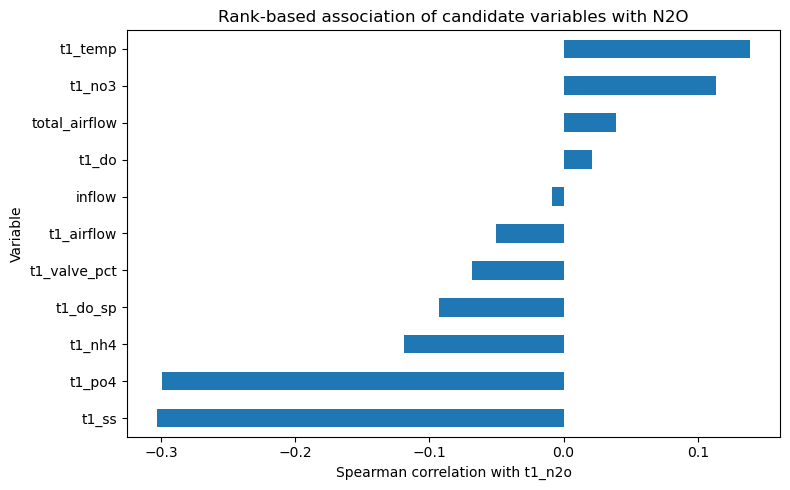

In [4]:
plt.figure(figsize=(8, 5))
spearman_corr.sort_values().plot(kind="barh")
plt.xlabel("Spearman correlation with t1_n2o")
plt.ylabel("Variable")
plt.title("Rank-based association of candidate variables with N2O")
plt.tight_layout()
plt.show()

The target-association results provide a first screening view, but they are not enough on their own to justify dropping variables. A predictor can have weak marginal association with `t1_n2o` and still add useful conditional information once other variables are included in a multivariable model.

For that reason, the next step is not to remove low-correlation variables immediately, but instead to examine whether some predictors are strongly overlapping with one another.

## 3. Examine redundancy between predictors

After checking association with the target, the next question is whether some predictors are carrying largely the same information. This matters because a variable can look important individually while still being unnecessary if another predictor already captures the same operational signal.

A predictor–predictor correlation matrix is useful here because it reveals clusters of variables that move together. In this dataset, the main concern is whether the control-related variables represent distinct inputs or overlapping versions of the same aeration-control behaviour.

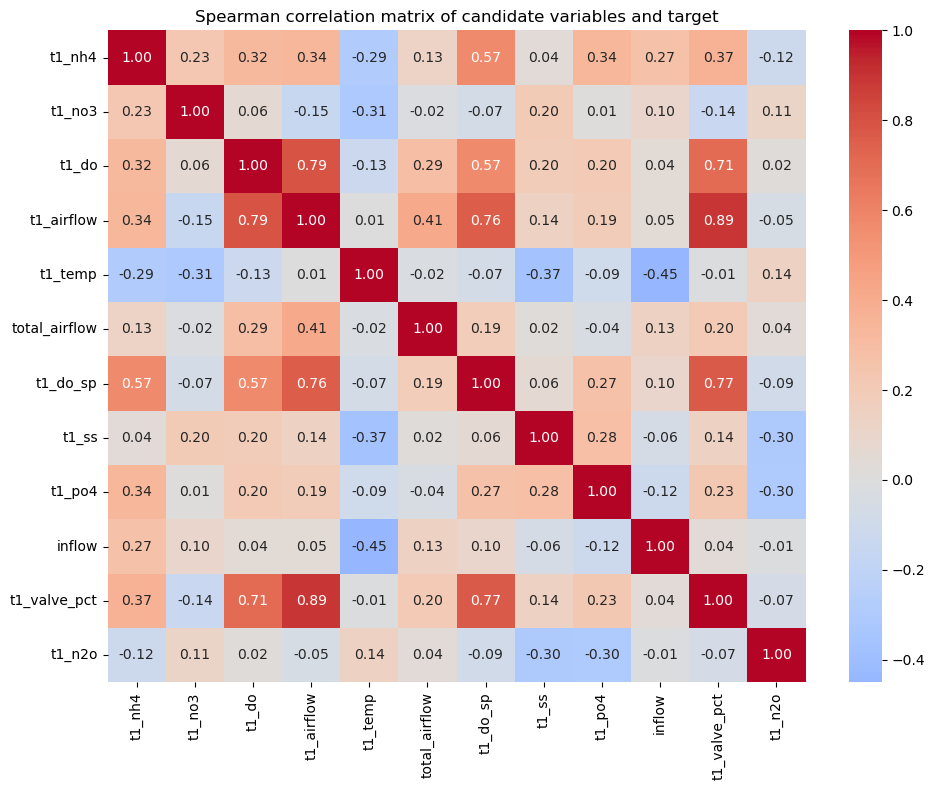

In [5]:
corr_vars = key_vars + [target]
corr_matrix = feature_df[corr_vars].corr(method="spearman")

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Spearman correlation matrix of candidate variables and target")
plt.tight_layout()
plt.show()

Correlation structure is a good first redundancy check, but pairwise correlation alone does not fully capture multicollinearity in a multivariable setting. A variable can be moderately correlated with several others and still become highly redundant when all predictors are considered together.

To quantify that more directly, the next step computes variance inflation factors (VIFs).

## 4. Quantify multicollinearity using VIF

VIF measures how strongly each predictor can be explained by the others. Large VIF values indicate that a predictor is not contributing much unique information and may cause instability or unnecessary complexity in later models.

This is particularly relevant here because the earlier correlation matrix suggests a cluster of related control variables. VIF helps identify which of those variables are the main redundancy candidates.

In [6]:
# Use complete cases for VIF calculation
vif_df = feature_df[key_vars].dropna().copy()

vif_results = pd.DataFrame({
    "variable": vif_df.columns,
    "VIF": [variance_inflation_factor(vif_df.values, i) for i in range(vif_df.shape[1])]
}).sort_values("VIF", ascending=False)

print("Initial VIF results:")
display(vif_results)

Initial VIF results:


,variable,VIF
3,t1_airflow,20.967962
10,t1_valve_pct,15.757825
5,total_airflow,11.679067
4,t1_temp,11.317663
6,t1_do_sp,9.073725
7,t1_ss,8.898342
2,t1_do,4.951817
9,inflow,3.016222
0,t1_nh4,3.012314
8,t1_po4,2.979449


To understand the highest-VIF results better, it is useful to inspect the correlation structure within the variables that appear most collinear. This makes it easier to see whether the high VIF values are being driven by one obvious control-variable cluster rather than by diffuse overlap across the whole feature set.

Spearman correlation among selected high-VIF variables:


,t1_airflow,t1_valve_pct,total_airflow,t1_temp,t1_ss,t1_do_sp,t1_do
t1_airflow,1.000000,0.891085,0.412332,0.007096,0.136450,0.756963,0.787357
t1_valve_pct,0.891085,1.000000,0.204446,-0.010564,0.141524,0.765207,0.706296
total_airflow,0.412332,0.204446,1.000000,-0.022559,0.021725,0.187116,0.289550
t1_temp,0.007096,-0.010564,-0.022559,1.000000,-0.369712,-0.072362,-0.127787
t1_ss,0.136450,0.141524,0.021725,-0.369712,1.000000,0.062460,0.195471
t1_do_sp,0.756963,0.765207,0.187116,-0.072362,0.062460,1.000000,0.572993
t1_do,0.787357,0.706296,0.289550,-0.127787,0.195471,0.572993,1.000000


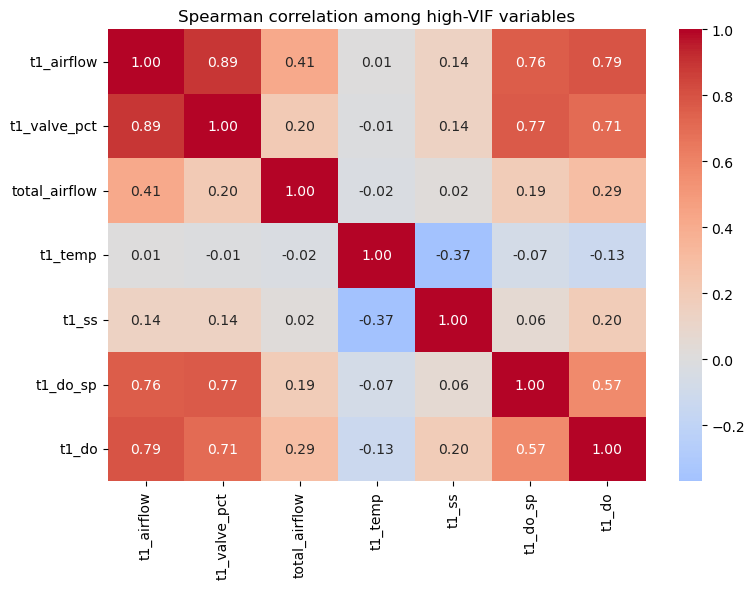

In [13]:
high_vif_vars = ["t1_airflow", "t1_valve_pct", "total_airflow", "t1_temp", "t1_ss", "t1_do_sp", "t1_do"]
high_vif_vars = [col for col in high_vif_vars if col in feature_df.columns]

high_vif_corr = feature_df[high_vif_vars].corr(method="spearman")

print("Spearman correlation among selected high-VIF variables:")
display(high_vif_corr)

plt.figure(figsize=(8, 6))
sns.heatmap(high_vif_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Spearman correlation among high-VIF variables")
plt.tight_layout()
plt.show()

Because the VIF and correlation results point especially strongly toward `t1_valve_pct` and `total_airflow` as redundancy candidates, it is useful to recalculate VIF after removing them. This does **not** prove that they should be dropped, but it shows whether the multicollinearity problem relaxes in the way expected if those variables are indeed duplicative.

In [8]:
vif_df2 = feature_df.drop(["t1_valve_pct", target], axis=1).dropna()

vif_results2 = pd.DataFrame({
    "variable": vif_df2.columns,
    "VIF": [variance_inflation_factor(vif_df2.values, i) for i in range(vif_df2.shape[1])]
}).sort_values("VIF", ascending=False)

vif_df3 = feature_df.drop(["t1_valve_pct", "total_airflow", target], axis=1).dropna()

vif_results3 = pd.DataFrame({
    "variable": vif_df3.columns,
    "VIF": [variance_inflation_factor(vif_df3.values, i) for i in range(vif_df3.shape[1])]
}).sort_values("VIF", ascending=False)

print("VIF after removing t1_valve_pct:")
display(vif_results2)

print("VIF after removing t1_valve_pct and total_airflow:")
display(vif_results3)

VIF after removing t1_valve_pct:


,variable,VIF
3,t1_airflow,10.864323
4,t1_temp,10.796788
5,total_airflow,10.165335
7,t1_ss,8.792582
6,t1_do_sp,8.001522
2,t1_do,4.869778
0,t1_nh4,3.011552
9,inflow,2.994543
8,t1_po4,2.978812
1,t1_no3,2.433807


VIF after removing t1_valve_pct and total_airflow:


,variable,VIF
3,t1_airflow,8.856156
6,t1_ss,8.662793
4,t1_temp,7.969357
5,t1_do_sp,7.470338
2,t1_do,4.845887
0,t1_nh4,2.966267
7,t1_po4,2.948991
8,inflow,2.691239
1,t1_no3,2.415091


## 5. Check whether removing redundant variables harms predictive performance

The correlation and VIF analyses identify *potential* redundancy, but they do not tell us whether a variable still improves predictions once the other variables are present. For feature selection, this is the key bridge between descriptive diagnostics and practical modelling.

To test that, the notebook next compares several fuller and reduced feature sets using a simple Ridge regression. Ridge is used here only as a regularised benchmark model for comparison; it is **not** intended to be the final modelling choice for `t1_n2o`.

In [9]:
feature_sets = {
    "Full set": [
        "t1_nh4", "t1_no3", "t1_do", "t1_airflow", "t1_temp",
        "total_airflow", "t1_do_sp", "t1_ss", "t1_po4",
        "inflow", "t1_valve_pct"
    ],
    "Without total_airflow": [
        "t1_nh4", "t1_no3", "t1_do", "t1_airflow", "t1_temp",
        "t1_do_sp", "t1_ss", "t1_po4", "inflow", "t1_valve_pct"
    ],
    "Without t1_valve_pct": [
        "t1_nh4", "t1_no3", "t1_do", "t1_airflow", "t1_temp",
        "total_airflow", "t1_do_sp", "t1_ss", "t1_po4", "inflow"
    ],
    "Without total_airflow and t1_valve_pct": [
        "t1_nh4", "t1_no3", "t1_do", "t1_airflow", "t1_temp",
        "t1_do_sp", "t1_ss", "t1_po4", "inflow"
    ],
    "Final retained set": [
        "t1_nh4", "t1_no3", "t1_do", "t1_airflow", "t1_temp",
        "t1_do_sp", "t1_ss", "t1_po4", "inflow"
    ],
}

feature_sets = {
    name: [col for col in cols if col in feature_df.columns]
    for name, cols in feature_sets.items()
}

results = []

for name, vars_used in feature_sets.items():
    model_df = feature_df[[target] + vars_used].dropna().copy()

    X = model_df[vars_used]
    y = model_df[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, shuffle=False
    )

    ridge_model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ])

    ridge_model.fit(X_train, y_train)
    y_pred = ridge_model.predict(X_test)

    results.append({
        "feature_set": name,
        "n_features": len(vars_used),
        "features_used": ", ".join(vars_used),
        "n_rows": len(model_df),
        "R2": r2_score(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred))
    })

results_df = pd.DataFrame(results).sort_values("RMSE")
display(results_df)

,feature_set,n_features,features_used,n_rows,R2,MAE,RMSE
2,Without t1_valve_pct,10,"t1_nh4, t1_no3, t1_do, t1_airflow, t1_temp, to...",79924,0.047790,0.099959,0.145173
0,Full set,11,"t1_nh4, t1_no3, t1_do, t1_airflow, t1_temp, to...",79924,0.047290,0.100011,0.145212
3,Without total_airflow and t1_valve_pct,9,"t1_nh4, t1_no3, t1_do, t1_airflow, t1_temp, t1...",79924,0.046768,0.100147,0.145251
4,Final retained set,9,"t1_nh4, t1_no3, t1_do, t1_airflow, t1_temp, t1...",79924,0.046768,0.100147,0.145251
1,Without total_airflow,10,"t1_nh4, t1_no3, t1_do, t1_airflow, t1_temp, t1...",79924,0.046388,0.100200,0.145280


The single train/test split is a useful first predictive check, but it still depends on one particular temporal split. Since wastewater process data are ordered in time, a more appropriate validation step is to use blocked time-series splits.

The next section therefore repeats the comparison using blocked time-series cross-validation. This checks whether the same redundancy conclusions still hold when the model is repeatedly evaluated on later temporal blocks rather than on one single holdout period.

## 6. Blocked time-series Ridge comparison

This first blocked comparison uses a simple imputation step so that all rows with observed target values can be retained. The goal is still comparative rather than predictive: we want to know whether reduced feature sets perform materially worse than the full set once the temporal structure of the data is respected.

In [10]:
full_features = [
    "t1_nh4",
    "t1_no3",
    "t1_do",
    "t1_airflow",
    "t1_temp",
    "t1_valve_pct",
    "total_airflow",
    "t1_do_sp",
    "t1_ss",
    "t1_po4",
    "inflow",
]

feature_sets_ts = {
    "full_set": full_features,
    "minus_t1_valve_pct": [f for f in full_features if f != "t1_valve_pct"],
    "minus_total_airflow": [f for f in full_features if f != "total_airflow"],
    "minus_both": [f for f in full_features if f not in ["t1_valve_pct", "total_airflow"]],
    "minus_t1_do_sp": [f for f in full_features if f != "t1_do_sp"],
    "minus_t1_airflow": [f for f in full_features if f != "t1_airflow"],
    "controls_compressed_keep_t1_airflow": [
        f for f in full_features
        if f not in ["t1_valve_pct", "total_airflow", "t1_do_sp"]
    ],
}

required_cols = list(set(full_features + [target]))
df_fs = df[required_cols].copy()
df_fs = df_fs.dropna(subset=[target]).reset_index(drop=True)

print(f"Rows available for feature-selection CV: {len(df_fs)}")

n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

def make_model_with_imputation():
    return Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ])

summary_rows = []
fold_rows = []

for set_name, features in feature_sets_ts.items():
    X = df_fs[features]
    y = df_fs[target]

    rmse_scores = []
    r2_scores = []

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model = make_model_with_imputation()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)

        rmse_scores.append(rmse)
        r2_scores.append(r2)

        fold_rows.append({
            "feature_set": set_name,
            "fold": fold,
            "n_features": len(features),
            "train_size": len(train_idx),
            "test_size": len(test_idx),
            "RMSE": rmse,
            "R2": r2
        })

    summary_rows.append({
        "feature_set": set_name,
        "n_features": len(features),
        "features": ", ".join(features),
        "RMSE_mean": np.mean(rmse_scores),
        "RMSE_std": np.std(rmse_scores, ddof=1),
        "R2_mean": np.mean(r2_scores),
        "R2_std": np.std(r2_scores, ddof=1)
    })

fold_results = pd.DataFrame(fold_rows)
summary_results = pd.DataFrame(summary_rows)

summary_results = summary_results.sort_values(
    by=["RMSE_mean", "R2_mean"],
    ascending=[True, False]
).reset_index(drop=True)

print("\nFold-by-fold results:")
display(fold_results)

print("\nSummary across time-series CV folds:")
display(summary_results)

print("\nCompact summary:")
display(summary_results[[
    "feature_set", "n_features", "RMSE_mean", "RMSE_std", "R2_mean", "R2_std"
]].copy())

Rows available for feature-selection CV: 102459

Fold-by-fold results:


,feature_set,fold,n_features,train_size,test_size,RMSE,R2
0,full_set,1,11,17079,17076,0.260708,-85.544510
1,full_set,2,11,34155,17076,0.431189,-0.501063
2,full_set,3,11,51231,17076,0.250879,-0.115254
3,full_set,4,11,68307,17076,0.164271,-2.289393
4,full_set,5,11,85383,17076,0.154331,-0.084264
5,minus_t1_valve_pct,1,10,17079,17076,0.260013,-85.083891
6,minus_t1_valve_pct,2,10,34155,17076,0.430508,-0.496328
7,minus_t1_valve_pct,3,10,51231,17076,0.250946,-0.115851
8,minus_t1_valve_pct,4,10,68307,17076,0.165162,-2.325160
9,minus_t1_valve_pct,5,10,85383,17076,0.154451,-0.085944



Summary across time-series CV folds:


,feature_set,n_features,features,RMSE_mean,RMSE_std,R2_mean,R2_std
0,controls_compressed_keep_t1_airflow,8,"t1_nh4, t1_no3, t1_do, t1_airflow, t1_temp, t1...",0.250816,0.110328,-17.271801,36.969775
1,minus_t1_do_sp,10,"t1_nh4, t1_no3, t1_do, t1_airflow, t1_temp, t1...",0.251309,0.110605,-17.661766,37.852901
2,minus_both,9,"t1_nh4, t1_no3, t1_do, t1_airflow, t1_temp, t1...",0.251736,0.110558,-17.328834,37.070561
3,minus_total_airflow,10,"t1_nh4, t1_no3, t1_do, t1_airflow, t1_temp, t1...",0.251769,0.110995,-17.338141,37.103865
4,minus_t1_airflow,10,"t1_nh4, t1_no3, t1_do, t1_temp, t1_valve_pct, ...",0.252158,0.111230,-17.677663,37.870226
5,minus_t1_valve_pct,10,"t1_nh4, t1_no3, t1_do, t1_airflow, t1_temp, to...",0.252216,0.110665,-17.621435,37.723889
6,full_set,11,"t1_nh4, t1_no3, t1_do, t1_airflow, t1_temp, t1...",0.252276,0.111154,-17.706897,37.933181



Compact summary:


,feature_set,n_features,RMSE_mean,RMSE_std,R2_mean,R2_std
0,controls_compressed_keep_t1_airflow,8,0.250816,0.110328,-17.271801,36.969775
1,minus_t1_do_sp,10,0.251309,0.110605,-17.661766,37.852901
2,minus_both,9,0.251736,0.110558,-17.328834,37.070561
3,minus_total_airflow,10,0.251769,0.110995,-17.338141,37.103865
4,minus_t1_airflow,10,0.252158,0.111230,-17.677663,37.870226
5,minus_t1_valve_pct,10,0.252216,0.110665,-17.621435,37.723889
6,full_set,11,0.252276,0.111154,-17.706897,37.933181


### Interpretation of blocked time-series Ridge comparison

The blocked time-series cross-validation results suggest that reducing the feature set does not harm predictive performance and may provide a small improvement. The full 11-variable set produced the highest mean RMSE (`0.252276`), while the best result was obtained from the more parsimonious 8-variable set that retained only `t1_airflow` from the control-related variables (`0.250816`). Although these differences are small, the important point is that removing `t1_valve_pct`, `total_airflow`, and `t1_do_sp` did not worsen performance. This supports the view that these variables are largely redundant once `t1_airflow` is included.

The $R^2$ values are negative for all feature sets, and the magnitudes are very large. A negative $R^2$ means that, on the corresponding test folds, the Ridge model performed worse than a simple baseline predictor that would always predict the mean of the target variable in that test set. In other words, the model is not explaining variation in `t1_n2o` effectively under these time-based splits. The large standard deviations also indicate that performance varied substantially across folds, suggesting that the data may contain different operating regimes or temporal structure that a simple linear Ridge model cannot capture well.

For this reason, the $R^2$ values should not be interpreted as evidence that the reduced feature sets are poor choices. Instead, they show that Ridge itself is a weak predictive model for this dataset in this validation setting. For feature selection, the more relevant result is the relative comparison between feature sets using RMSE, though this analysis on the whole may not be particularly informative. Since the simpler reduced sets performed as well as or slightly better than the full set, the analysis provides additional evidence for carrying forward a more parsimonious subset of variables rather than retaining all 11 predictors.

Because the imputed blocked comparison mixes rows with different missing-data patterns, it is useful to repeat the check on each feature set's own complete-case subset as well. This makes the comparison more directly comparable to the earlier single-split analysis and helps verify that the conclusion is not just an artefact of the imputation step.

The next section therefore reruns the blocked comparison using complete cases for each feature set separately.

In [11]:
target = "t1_n2o"

feature_sets = {
    "full_set": [
        "t1_nh4", "t1_no3", "t1_do", "t1_airflow", "t1_temp",
        "t1_valve_pct", "total_airflow", "t1_do_sp",
        "t1_ss", "t1_po4", "inflow"
    ],
    "minus_t1_valve_pct": [
        "t1_nh4", "t1_no3", "t1_do", "t1_airflow", "t1_temp",
        "total_airflow", "t1_do_sp", "t1_ss", "t1_po4", "inflow"
    ],
    "minus_total_airflow": [
        "t1_nh4", "t1_no3", "t1_do", "t1_airflow", "t1_temp",
        "t1_valve_pct", "t1_do_sp", "t1_ss", "t1_po4", "inflow"
    ],
    "minus_both": [
        "t1_nh4", "t1_no3", "t1_do", "t1_airflow", "t1_temp",
        "t1_do_sp", "t1_ss", "t1_po4", "inflow"
    ],
    "minus_t1_do_sp": [
        "t1_nh4", "t1_no3", "t1_do", "t1_airflow", "t1_temp",
        "t1_valve_pct", "total_airflow", "t1_ss", "t1_po4", "inflow"
    ],
    "minus_t1_airflow": [
        "t1_nh4", "t1_no3", "t1_do", "t1_temp",
        "t1_valve_pct", "total_airflow", "t1_do_sp",
        "t1_ss", "t1_po4", "inflow"
    ],
    "controls_compressed_keep_t1_airflow": [
        "t1_nh4", "t1_no3", "t1_do", "t1_airflow", "t1_temp",
        "t1_ss", "t1_po4", "inflow"
    ]
}

# Keep only columns that actually exist
feature_sets = {
    name: [col for col in cols if col in feature_df.columns]
    for name, cols in feature_sets.items()
}

# -----------------------------------
# 2. CV settings and model
# -----------------------------------
n_splits = 5
tscv = TimeSeriesSplit(n_splits=n_splits)

def make_model():
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0))
    ])

# -----------------------------------
# 3. Evaluate each feature set on its
#    own complete-case subset
# -----------------------------------
fold_rows = []
summary_rows = []

for set_name, vars_used in feature_sets.items():
    model_df = feature_df[[target] + vars_used].dropna().copy()

    X = model_df[vars_used]
    y = model_df[target]

    rmse_scores = []
    r2_scores = []
    mae_scores = []

    for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model = make_model()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        r2 = r2_score(y_test, y_pred)
        mae = mean_absolute_error(y_test, y_pred)

        rmse_scores.append(rmse)
        r2_scores.append(r2)
        mae_scores.append(mae)

        fold_rows.append({
            "feature_set": set_name,
            "fold": fold,
            "n_rows": len(model_df),
            "n_features": len(vars_used),
            "train_size": len(train_idx),
            "test_size": len(test_idx),
            "RMSE": rmse,
            "MAE": mae,
            "R2": r2
        })

    summary_rows.append({
        "feature_set": set_name,
        "n_rows": len(model_df),
        "n_features": len(vars_used),
        "features_used": ", ".join(vars_used),
        "RMSE_mean": np.mean(rmse_scores),
        "RMSE_std": np.std(rmse_scores, ddof=1),
        "RMSE_median": np.median(rmse_scores),
        "MAE_mean": np.mean(mae_scores),
        "MAE_std": np.std(mae_scores, ddof=1),
        "R2_mean": np.mean(r2_scores),
        "R2_std": np.std(r2_scores, ddof=1),
        "R2_median": np.median(r2_scores)
    })

fold_results = pd.DataFrame(fold_rows)
summary_results = pd.DataFrame(summary_rows).sort_values(
    by=["RMSE_mean", "RMSE_median", "MAE_mean"],
    ascending=[True, True, True]
).reset_index(drop=True)

print("\nFold-by-fold results:")
display(fold_results)

print("\nSummary across blocked time-series CV folds:")
display(summary_results)

print("\nCompact summary:")
display(summary_results[[
    "feature_set", "n_rows", "n_features",
    "RMSE_mean", "RMSE_std", "RMSE_median",
    "MAE_mean", "MAE_std",
    "R2_mean", "R2_std", "R2_median"
]])


Fold-by-fold results:


,feature_set,fold,n_rows,n_features,train_size,test_size,RMSE,MAE,R2
0,full_set,1,79924,11,13324,13320,0.347058,0.183017,-0.279027
1,full_set,2,79924,11,26644,13320,0.364934,0.220667,-0.224973
2,full_set,3,79924,11,39964,13320,0.167688,0.150183,-23.246649
3,full_set,4,79924,11,53284,13320,0.145420,0.125102,-0.225356
4,full_set,5,79924,11,66604,13320,0.139451,0.092360,0.052663
5,minus_t1_valve_pct,1,79924,10,13324,13320,0.347110,0.183107,-0.279406
6,minus_t1_valve_pct,2,79924,10,26644,13320,0.364957,0.220822,-0.225131
7,minus_t1_valve_pct,3,79924,10,39964,13320,0.167590,0.150067,-23.218197
8,minus_t1_valve_pct,4,79924,10,53284,13320,0.145454,0.125153,-0.225927
9,minus_t1_valve_pct,5,79924,10,66604,13320,0.139449,0.092354,0.052685



Summary across blocked time-series CV folds:


,feature_set,n_rows,n_features,features_used,RMSE_mean,RMSE_std,RMSE_median,MAE_mean,MAE_std,R2_mean,R2_std,R2_median
0,controls_compressed_keep_t1_airflow,88643,8,"t1_nh4, t1_no3, t1_do, t1_airflow, t1_temp, t1...",0.230773,0.136640,0.161319,0.159107,0.085757,-1.031012,1.596655,-0.522803
1,minus_t1_do_sp,88628,10,"t1_nh4, t1_no3, t1_do, t1_airflow, t1_temp, t1...",0.231553,0.136071,0.163650,0.159524,0.085548,-1.063616,1.665148,-0.522614
2,minus_both,79924,9,"t1_nh4, t1_no3, t1_do, t1_airflow, t1_temp, t1...",0.232425,0.112587,0.167591,0.153913,0.049441,-4.774972,10.311025,-0.219209
3,minus_total_airflow,79924,10,"t1_nh4, t1_no3, t1_do, t1_airflow, t1_temp, t1...",0.232515,0.112636,0.167710,0.153962,0.049478,-4.782437,10.326097,-0.220621
4,minus_t1_airflow,79955,10,"t1_nh4, t1_no3, t1_do, t1_temp, t1_valve_pct, ...",0.232881,0.112925,0.167062,0.154460,0.049342,-4.617183,9.941403,-0.230779
5,full_set,79924,11,"t1_nh4, t1_no3, t1_do, t1_airflow, t1_temp, t1...",0.232910,0.113030,0.167688,0.154266,0.049838,-4.784668,10.321379,-0.225356
6,minus_t1_valve_pct,79924,10,"t1_nh4, t1_no3, t1_do, t1_airflow, t1_temp, to...",0.232912,0.113058,0.167590,0.154300,0.049899,-4.779195,10.308537,-0.225927



Compact summary:


,feature_set,n_rows,n_features,RMSE_mean,RMSE_std,RMSE_median,MAE_mean,MAE_std,R2_mean,R2_std,R2_median
0,controls_compressed_keep_t1_airflow,88643,8,0.230773,0.136640,0.161319,0.159107,0.085757,-1.031012,1.596655,-0.522803
1,minus_t1_do_sp,88628,10,0.231553,0.136071,0.163650,0.159524,0.085548,-1.063616,1.665148,-0.522614
2,minus_both,79924,9,0.232425,0.112587,0.167591,0.153913,0.049441,-4.774972,10.311025,-0.219209
3,minus_total_airflow,79924,10,0.232515,0.112636,0.167710,0.153962,0.049478,-4.782437,10.326097,-0.220621
4,minus_t1_airflow,79955,10,0.232881,0.112925,0.167062,0.154460,0.049342,-4.617183,9.941403,-0.230779
5,full_set,79924,11,0.232910,0.113030,0.167688,0.154266,0.049838,-4.784668,10.321379,-0.225356
6,minus_t1_valve_pct,79924,10,0.232912,0.113058,0.167590,0.154300,0.049899,-4.779195,10.308537,-0.225927


### Interpretation of blocked time-series Ridge comparison on complete-case subsets

This revised blocked time-series Ridge comparison is more directly comparable to the earlier single-split analysis because each feature set is now evaluated on its own complete-case subset, rather than on a shared imputed dataset. Among the feature sets evaluated on the same 79,924-row subset, the reduced models performed at least as well as the full model, and in several folds slightly better. In particular, removing `total_airflow` consistently reduced RMSE relative to the full feature set, while removing both `total_airflow` and `t1_valve_pct` gave the lowest RMSE in most folds. This suggests that these variables do not add meaningful predictive value in the presence of the remaining features and are likely redundant.

The `R^2` values remain negative for most folds, with one fold showing especially large negative values across all feature sets. A negative `R^2` means that the Ridge model performed worse than a baseline predictor that simply uses the mean of the target in that test fold. This indicates that Ridge is not a strong predictive model for all parts of the time series and that some temporal blocks are substantially harder to predict than others. However, for feature-selection purposes the more important result is the relative comparison between feature sets. Since the reduced sets match or slightly outperform the full set, the analysis provides additional evidence for dropping `total_airflow`, and supports dropping `t1_valve_pct` on parsimony grounds as well.

## 7. Optional supporting filter check: mRMR

As a final supporting check, the notebook computes a simple greedy mRMR-style ranking using mutual information for relevance and average absolute Spearman correlation for redundancy. This is not used as the main decision rule; it is included only as an additional filter-style view of the same relevance-versus-redundancy trade-off examined above.

The main selection decision remains based on the combined evidence from target association, redundancy diagnostics, and reduced-set model comparisons.

In [12]:
# mRMR (filter method) using Mutual Information (relevance) - Correlation (redundancy)
from sklearn.feature_selection import mutual_info_regression

candidate_vars = model_vars if "model_vars" in globals() else key_vars
candidate_vars = [c for c in candidate_vars if c in feature_df.columns and c != target]

# Use complete cases for stable MI / correlation estimation
mrmr_df = feature_df[[target] + candidate_vars].dropna().copy()
X = mrmr_df[candidate_vars]
y = mrmr_df[target]

# Mutual information relevance scores
mi = mutual_info_regression(X, y, random_state=42)
mi_series = pd.Series(mi, index=candidate_vars)

# Correlation matrix for redundancy 
corr = X.corr(method="spearman").abs()

def mrmr_select(mi_scores: pd.Series, corr_abs: pd.DataFrame, k: int = 10):
    """
    Greedy mRMR:
    score(feature) = MI(feature; y) - mean_{selected}(corr(feature, selected))
    Returns selected features and a step-by-step table.
    """
    selected = []
    steps = []

    # start with the most relevant feature
    first = mi_scores.sort_values(ascending=False).index[0]
    selected.append(first)
    steps.append({
        "step": 1,
        "selected_feature": first,
        "MI": mi_scores[first],
        "mean_redundancy": 0.0,
        "mRMR_score": mi_scores[first]
    })

    while len(selected) < min(k, len(mi_scores)):
        remaining = [f for f in mi_scores.index if f not in selected]
        best_f, best_score, best_red = None, -np.inf, None

        for f in remaining:
            redundancy = corr_abs.loc[f, selected].mean() if len(selected) > 0 else 0.0
            score = mi_scores[f] - redundancy
            if score > best_score:
                best_f, best_score, best_red = f, score, redundancy

        selected.append(best_f)
        steps.append({
            "step": len(selected),
            "selected_feature": best_f,
            "MI": mi_scores[best_f],
            "mean_redundancy": float(best_red),
            "mRMR_score": float(best_score)
        })

    return selected, pd.DataFrame(steps)

k = 10  # choose how many features you want to rank/select
selected_feats, mrmr_table = mrmr_select(mi_series, corr, k=k)

print(f"Top-{k} mRMR selected features:")
print(selected_feats)

print("\nmRMR selection trace:")
display(mrmr_table)

# Optional: full ranking table (useful for reporting)
ranking = pd.DataFrame({
    "MI_relevance": mi_series,
    "avg_abs_corr_to_others": corr.mean(axis=1)
}).sort_values("MI_relevance", ascending=False)

print("\nRelevance/redundancy summary:")
display(ranking)

Top-10 mRMR selected features:
['t1_temp', 't1_do', 't1_ss', 't1_po4', 't1_no3', 'inflow', 'total_airflow', 't1_nh4', 't1_valve_pct', 't1_do_sp']

mRMR selection trace:


,step,selected_feature,MI,mean_redundancy,mRMR_score
0,1,t1_temp,0.431151,0.000000,0.431151
1,2,t1_do,0.227745,0.073303,0.154442
2,3,t1_ss,0.236751,0.193705,0.043046
3,4,t1_po4,0.120312,0.155603,-0.035291
4,5,t1_no3,0.109162,0.119263,-0.010101
5,6,inflow,0.144354,0.162081,-0.017727
6,7,total_airflow,0.042647,0.106571,-0.063923
7,8,t1_nh4,0.105729,0.240696,-0.134967
8,9,t1_valve_pct,0.063471,0.225337,-0.161867
9,10,t1_do_sp,0.055327,0.297409,-0.242082



Relevance/redundancy summary:


,MI_relevance,avg_abs_corr_to_others
t1_temp,0.431151,0.233983
t1_ss,0.236751,0.209258
t1_do,0.227745,0.377481
inflow,0.144354,0.217855
t1_po4,0.120312,0.247721
t1_no3,0.109162,0.206784
t1_nh4,0.105729,0.357047
t1_valve_pct,0.063471,0.404551
t1_do_sp,0.055327,0.402924
total_airflow,0.042647,0.231277


## Final summary and selected feature set

This notebook assessed feature relevance and redundancy using several complementary steps: association with the target variable `t1_n2o`, correlation between predictors, multicollinearity diagnostics using VIF, and simple Ridge-based comparison of reduced feature sets. Taken together, these analyses support carrying forward the following reduced set of variables for subsequent modelling:

```python
features = [
    "t1_nh4",
    "t1_no3",
    "t1_airflow",
    "t1_temp",
    "t1_ss",
    "t1_po4",
    "inflow"
]

The initial target-association analysis showed that `t1_ss` and `t1_po4` had some of the strongest relationships with `t1_n2o`, while `t1_temp`, `t1_nh4`, and `t1_no3` also showed meaningful signal. Although `inflow` has a weaker marginal relationship with the target, it was retained because weak univariate association alone is not sufficient reason to remove a variable that may still contribute useful conditional information in a multivariable setting. In process data, variables can remain informative even when their standalone correlation with the target is modest. However, `t1_do` will be dropped due to the fact that it too exhibits a negligible correlation with `t1_n2o` *and* it is highly correlated with `t1_airflow`. As such, the inclusion of this feature to avoid possibily losing a marginal signal may imbue future models with significant multicollinearity, indicating that excluding it is a pertinent choice.

The predictor correlation analysis showed a clear cluster of strongly related control variables, particularly `t1_airflow`, `t1_valve_pct`, `t1_do_sp`, and `total_airflow`. This indicated that these variables were capturing overlapping operational information rather than four fully distinct sources of signal. The VIF analysis reinforced this conclusion, with these same variables exhibiting the strongest multicollinearity. This made them the primary candidates for removal on redundancy grounds.

The subsequent reduced-set Ridge comparisons supported this interpretation. Across the tested feature sets, removing `total_airflow` and `t1_valve_pct` did not worsen predictive performance and in several comparisons slightly improved it relative to the full set. This suggests that both variables were adding little additional information once the remaining process variables were included. More broadly, the reduced feature sets performed similarly to the full feature set, indicating that a more parsimonious specification is justified.

Within the correlated control-variable group, `t1_airflow` was retained as the single representative variable. It captures direct operational control information and allows the feature set to preserve the main aeration-related signal without carrying multiple highly overlapping predictors. By contrast, `t1_valve_pct`, `t1_do_sp`, and `total_airflow` were excluded because the earlier correlation structure, VIF results, and reduced-model comparisons all suggested substantial redundancy. `total_airflow` showed the clearest case for removal, while `t1_valve_pct` and `t1_do_sp` were also judged unnecessary once `t1_airflow` was retained.

Overall, the final selected feature set balances two aims: retaining variables with plausible process relevance and observed association with `t1_n2o`, while removing variables whose information appears to be duplicated elsewhere in the dataset. The retained set therefore preserves the main chemical, operational, and loading-related signals (`t1_nh4`, `t1_no3`, `t1_do`, `t1_airflow`, `t1_temp`, `t1_ss`, `t1_po4`, and `inflow`) while excluding the most clearly redundant predictors. This provides a more interpretable and parsimonious basis for later modelling.